### Challenge 16
Revisit the last challenge, add a function that calculates the exact solution, and one that calculates the local
error and the global error for h = .1, .5, 1, 1.5, 
plot the error


Step size h = 0.1
Max global error: 0.04019944117144231
Max local error: 0.018730753077981777

Step size h = 0.5
Max global error: 0.36787944117144233
Max local error: 0.36787944117144233

Step size h = 1
Max global error: 1.1353352832366128
Max local error: 1.1353352832366128

Step size h = 1.5
Max global error: 63.99999999793884
Max local error: 2.0356739933472525


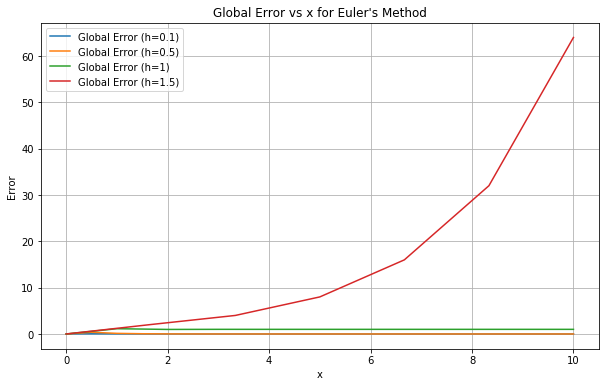

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Exact solution: y = e^(-2x)
def exact_solution(x):
    return np.exp(-2 * x)

# Function dy/dx = -2y
def f(x, y):
    return -2 * y

# Step sizes to test
step_sizes = [0.1, 0.5, 1, 1.5]

x_start, x_end = 0, 10
plt.figure(figsize=(10,6))

for h in step_sizes:

    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1

    # Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Exact solution at same points
    y_exact = exact_solution(x_values)

    # Global error (difference at each point)
    global_error = np.abs(y_values - y_exact)

    # Local error (one-step error)
    local_error = np.zeros(num_steps)

    for i in range(num_steps):
        true_current = y_exact[i]  
        euler_step = true_current + h * f(x_values[i], true_current)
        true_next = y_exact[i+1]

        local_error[i] = abs(true_next - euler_step)

    # Print summary
    print(f"\nStep size h = {h}")
    print("Max global error:", np.max(global_error))
    print("Max local error:", np.max(local_error))

    # Plot global error
    plt.plot(x_values, global_error, label=f"Global Error (h={h})")
    
plt.xlabel('x')
plt.ylabel('Error')
plt.title("Global Error vs x for Euler's Method")
plt.legend()
plt.grid()
plt.show()

**Comments:** Global error increases rapidly with h - the jump from h=1 to h=1.5 is especially large. 